In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [57]:
ds_path = "../original_ds/imdb.csv"
ds = pd.read_csv(ds_path, na_values=['\\N'])

# print shape
print(f"Shape of the dataset: {ds.shape}")

Shape of the dataset: (149531, 32)


In [58]:
# drop columns with all same values
def dropColumnWithOnlyOneUniqueValue(ds):
    print("Columns dropped: ", end="")
    # print column names with one unique value
    for col in ds.columns:
        if ds[col].nunique() == 1:
            print(col, end=" ")
    # drop columns with one unique value
    ds_dropped = ds.drop(columns=ds.columns[ds.nunique() == 1])
    # print number of columns
    return ds_dropped

ds = dropColumnWithOnlyOneUniqueValue(ds)

Columns dropped: worstRating bestRating isRatable 

In [59]:
def clean_column_lists(ds, column):
    """
    Clean the specified column by removing '\\N' elements from lists.
    If the list becomes empty after removal, set the cell to NaN.
    """
    def clean_list(lst):
        if isinstance(lst, float) and np.isnan(lst):
            return np.nan
        # Remove '\\N' elements and strip spaces
        cleaned_list = [item.strip() for item in lst if item.strip() and item.strip() != '\\N']
        # Return NaN if the list is empty, otherwise return the cleaned list
        return np.nan if not cleaned_list else cleaned_list

    # Convert the column to string and strip square brackets and single quotes
    ds[column] = ds[column].astype(str).str.strip("[]").str.replace("'", "")
    # Remove occurrences of '\\N'
    ds[column] = ds[column].str.replace(r"\\\\N", "", regex=True)
    # Split the string into a list, or set to NaN if empty
    ds[column] = ds[column].apply(lambda x: x.split(",") if x.strip() else np.nan)
    # Clean the lists
    ds[column] = ds[column].apply(clean_list)
    # Replace 'nan' strings with np.nan
    ds[column] = ds[column].apply(lambda x: np.nan if isinstance(x, list) and 'nan' in x else x)
    return ds

In [60]:
clean_column_lists(ds, 'regions')
clean_column_lists(ds, 'genres')
clean_column_lists(ds, 'countryOfOrigin')
clean_column_lists(ds, 'soundMixes')
print("Done.")

Done.


In [61]:
types = ds.dtypes.to_dict() # create a dictionary with the type of each column
# group the columns by type
grouped = {}
for col, type in types.items():
    if type not in grouped:
        grouped[type] = []
    grouped[type].append(col)

for type, cols in grouped.items():
    print(f"{type}: {cols}\n")

print("Done.")


object: ['originalTitle', 'rating', 'titleType', 'countryOfOrigin', 'genres', 'regions', 'soundMixes']

int64: ['startYear', 'awardWins', 'numVotes', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'isAdult', 'numRegions', 'userReviewsTotal', 'ratingCount', 'castNumber', 'companiesNumber', 'externalLinks', 'writerCredits', 'directorsCredits', 'quotesTotal']

float64: ['endYear', 'runtimeMinutes', 'averageRating']

bool: ['canHaveEpisodes']

Done.


# Most common value in the ds

In [62]:
# # create a dataframe with columns "column name", "most common value", "frequency", "percentage"
# most_common = []

# for col in ds.columns:
#     most_common_value = ds[col].mode().values[0]
#     frequency = ds[col].value_counts().max()
#     percentage = frequency / len(ds) * 100
#     most_common.append([col, most_common_value, frequency, percentage])

# # store the results in a dataframe
# df_most_common = pd.DataFrame(most_common, columns=["column name", "most common value", "frequency", "percentage"])

# # store the results in a csv file
# df_most_common.to_csv("./data_overview/sheets/most_common.csv", index=False)
# print("Done.")


# Plots

In [63]:
# sns.set_theme(palette="viridis")        
# _folder = "./data_overview/histograms/" # Cartella dove salvare i grafici
# os.makedirs(_folder, exist_ok=True)     # Crea la cartella se non esiste

# # numCols merges types dictionary defined above for all numeric types
# numCols = grouped[np.dtype('int64')] + grouped[np.dtype('float64')]

# # Crea un istogramma per ogni colonna numerica
# for col in numCols:
#     plt.figure(figsize=(4, 3))
#     sns.histplot(data = ds, x=col, bins = 100, legend= False)  # Istogramma con colormap
#     plt.yscale('log')  # Scala logaritmica per asse Y
#     plt.title(col, fontsize=14, fontweight="bold")
#     plt.xlabel("Valore")
#     plt.ylabel("Frequenza (log)")
#     plt.xticks(rotation=45)

#     # Salva il grafico con un percorso corretto
#     filepath = os.path.join(_folder, f"{col}.png")
#     plt.savefig(filepath, dpi=300, bbox_inches="tight")

#     plt.close()

# print("Done")

# Object analysis

In [64]:
def create_info_df(ds):
    df_info_list = []  # Use a list to store dictionaries and then convert to DataFrame
    
    for col in ds.columns:
        distinct_values = ds[col].nunique()
        missing_values = ds[col].isnull().sum()
        most_common_value = ds[col].mode().values[0] if not ds[col].mode().empty else None
        percentage = (ds[col].value_counts().max() / len(ds) * 100) if not ds[col].empty else 0
        
        df_info_list.append({
            "column": col,
            "distinct values": distinct_values,
            "missing values": missing_values,
            "most common value": most_common_value,
            "percentage": percentage
        })
    
    return pd.DataFrame(df_info_list)  # Convert list to DataFrame

In [65]:
def plot_missing_values(ds, save_path):
    """
    Plot the percentage of missing values for each column in the dataset.
    
    Parameters:
    ds (pd.DataFrame): The dataset.
    save_path (str): The path where the plot will be saved.
    """
    missing_values = ds.isna().mean() * 100

    # Plot delle percentuali di valori mancanti per ogni colonna
    plt.figure(figsize=(6, 2.5))
    # Inverti gli assi x e y
    sns.barplot(y=missing_values[missing_values > 0].index, x=missing_values[missing_values > 0])
    plt.xticks(rotation=45)
    plt.title("Percentage of missing values grouped by feature")
    # Nessuna etichetta per l'asse y
    plt.ylabel("")
    plt.xlabel("")
    # Etichette dell'asse x come percentuali
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    # Percentuale a destra di ogni barra
    for i, v in enumerate(missing_values[missing_values > 0]):
        plt.text(v, i, f"{v:.2f}%", color='black', va='center')
    # Cambia colore per ogni barra
    for i, bar in enumerate(plt.gca().patches):
        bar.set_color(plt.cm.viridis(i / len(missing_values[missing_values > 0])))
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

In [66]:
plot_missing_values(ds, "./data_overview/misc/missing_values_original.png")

# Standardize `originalTitle`

In [67]:
import pandas as pd

def standardize_titles(ds):
    # standardize the `originalTitle` column
    # transform lists of strings into a single string
    ds["originalTitle"] = ds["originalTitle"].apply(lambda x: " ".join(x.split(",")) if isinstance(x, str) and "," in x else x)
    ds["originalTitle"] = ds["originalTitle"].apply(lambda x: " ".join(x) if isinstance(x, list) else x)
    # make everything lowercase
    ds["originalTitle"] = ds["originalTitle"].str.lower()
    # remove all special characters
    ds["originalTitle"] = ds["originalTitle"].str.replace(r"[^a-z0-9 ]", "", regex=True)
    # remove multiple spaces
    ds["originalTitle"] = ds["originalTitle"].str.replace(r"\s+", " ", regex=True)
    # remove leading and trailing spaces
    ds["originalTitle"] = ds["originalTitle"].str.strip()

    return ds

ds = standardize_titles(ds)

In [68]:
# Imposta la figura
plt.figure(figsize=(5, 3))

# Crea un istogramma ORIZZONTALE
ax = sns.countplot(data=ds, y="titleType", palette="viridis", legend=False, hue = "titleType")
plt.ylabel("")
plt.xlabel("")
# Titolo del grafico
plt.title("Number of entries by titleType")

# Aggiungi le percentuali accanto a ogni barra
total = len(ds)
for bar in ax.patches:
    width = bar.get_width()  # Lunghezza della barra
    percentage = f"{(width / total) * 100:.2f}%"  # Calcolo corretto della percentuale
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, percentage, 
            va='center', fontsize=10, color='black')

# Mostra il grafico
plt.tight_layout()
# plt.show()
plt.savefig("./data_overview/misc/titleType_old_groupedBy.png", dpi=300)
plt.close()

In [69]:
ds["titleType"] = ds["titleType"].replace({
    "tvShort": "short",             # merged with short
    "tvMiniSeries": "tvSeries",     # merged with tvSeries
    "tvSpecial": "tvEpisode",        # merged with tvEpisode
    "tvMovie": "movie"              # merged with movie
})

In [70]:
# drop rows with titleType = "videoGame"
ds = ds[ds["titleType"] != "videoGame"]

In [71]:
# Imposta la figura
plt.figure(figsize=(4, 2))
ax = sns.countplot(data=ds, y="titleType", palette="viridis", legend=False, hue = "titleType")
plt.ylabel("")
plt.xlabel("")
plt.title("Percentage of records by titleType")
total = len(ds)
for bar in ax.patches:
    width = bar.get_width() 
    percentage = f"{(width / total) * 100:.2f}%"
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, percentage, 
            va='center', fontsize=10, color='black')

sns.despine(ax=ax, top=True, right=True, bottom=True)

plt.tight_layout()
# plt.show()
plt.savefig("./data_overview/misc/titleType_new_groupedBy.png", dpi=300)
plt.close()

In [72]:
# print all possible couples in ds {canHaveEpisode, titleType}
print(ds.groupby(["titleType", "canHaveEpisodes"]).size())

# print originalTitle and startYear of short which can have episodes
print("--- short ---")
print(ds[(ds["canHaveEpisodes"] == True) & (ds["titleType"] == "short")][["originalTitle", "startYear"]])

# print originalTitle and startYear of tvMovie which can have episodes
print("--- tvMovie ---")
print(ds[(ds["canHaveEpisodes"] == True) & (ds["titleType"] == "tvMovie")][["originalTitle", "startYear"]])

# print originalTitle and startYear of movie which can have episodes
print("--- movie ---")
print(ds[(ds["canHaveEpisodes"] == True) & (ds["titleType"] == "movie")][["originalTitle", "startYear"]])

titleType  canHaveEpisodes
movie      False              43153
           True                   2
short      False              16646
           True                   1
tvEpisode  False              71979
tvSeries   True               10824
video      False               5149
dtype: int64
--- short ---
       originalTitle  startYear
114248  the haunting       2023
--- tvMovie ---
Empty DataFrame
Columns: [originalTitle, startYear]
Index: []
--- movie ---
                                            originalTitle  startYear
87338                                              unlock       2020
117934  the murder of lyn dawson the teacher the groom...       2023


In [73]:
# Define the categories to filter
categories_to_filter = ["tvMovie", "short", "movie"]

# Count the number of entries to be dropped
entries_to_drop = ds[(ds['canHaveEpisodes'] == True) & (ds['titleType'].isin(categories_to_filter))].shape[0]

# Drop the entries
ds = ds[~((ds['canHaveEpisodes'] == True) & (ds['titleType'].isin(categories_to_filter)))]

# Print the number of entries dropped
print(f"Number of entries dropped: {entries_to_drop}")

Number of entries dropped: 3


# `startYear` manipulation

In [74]:
# create a new column with the decade
ds["startYearDecade"] = ds["startYear"] // 10 * 10
#print(ds["startYearDecade"].value_counts().sort_index())
print("Done.")

Done.


In [75]:
# Imposta la figura
plt.figure(figsize=(10, 5))

# Crea il countplot
ax = sns.countplot(data=ds, x="startYear", legend=False, palette="viridis", hue = "startYear")

# Titolo del grafico
plt.title("Number of entries by `startYear`")

min_year = ds["startYear"].min()
max_year = ds["startYear"].max()

#remove x labels
plt.xticks([])

# Migliora il layout
plt.tight_layout()

# Mostra il grafico
#plt.show()
# salva
plt.savefig("./data_overview/misc/startYear_distribution.png", dpi=300)
# Chiude la figura
plt.close()

In [76]:
# Imposta la figura
plt.figure(figsize=(5, 4))

# Crea il countplot (invertendo gli assi)
ax = sns.countplot(data=ds, y="startYearDecade", palette="viridis", legend=False, hue="startYearDecade")

# Rimuovi il titolo dell'asse x
plt.ylabel("")
# Ruota le etichette dell'asse y
plt.xticks(rotation=90)
# Rimuovi il titolo dell'asse y
plt.xlabel("")

# Aggiungi le percentuali, allineate verticalmente
total = len(ds)
for bar in ax.patches:
    width = bar.get_width()  # Lunghezza della barra (ora la larghezza rappresenta la frequenza)
    percentage = f"{(width / total) * 100:.2f}%"  # Calcolo corretto della percentuale
    # Posiziona il testo al centro del grafico in verticale, allineato con l'asse Y
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, percentage, 
            va='center', fontsize=10, color='black')

# Titolo del grafico
plt.title("Number of records by `startYearDecade`")

# Migliora il layout
plt.tight_layout()

#plt.show()
plt.savefig("./data_overview/misc/startYearDecade_distribution_percentage.png", dpi=300)
plt.close()

In [77]:
# Calcola la percentuale di valori presenti per ogni titleType
present_values = ds.groupby('titleType')['endYear'].apply(lambda x: x.notna().mean() * 100)

# Crea un DataFrame con i valori presenti
data = pd.DataFrame({
    'titleType': present_values.index,
    'present': present_values
})

plt.figure(figsize=(6, 4))
# Inverti gli assi x e y
sns.barplot(y='titleType', x='present', data=data, palette="viridis", hue='titleType')
plt.xticks(rotation=45)
plt.title("Present values in `endYear` grouped by `titleType` (%)")
# Nessuna etichetta per l'asse y
plt.ylabel("")
plt.xlabel("")
# Etichette dell'asse x come percentuali
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
# Percentuale a destra di ogni barra
for i, v in enumerate(data['present']):
    if v != 0:
        plt.text(v, i, f"{v:.2f}%", color='black', va='center')
plt.tight_layout()
plt.savefig("./data_overview/misc/endYear_new_percentage.png", dpi=300)
plt.close()
print("Done")

Done


In [78]:
# print percentage of missing values in endYear grouped by titleType
print(ds.groupby("titleType")["endYear"].apply(lambda x: x.isna().mean() * 100))

titleType
movie        100.000000
short        100.000000
tvEpisode    100.000000
tvSeries      47.949002
video        100.000000
Name: endYear, dtype: float64


# `rating` column

In [24]:
def print_correlation_matrix(ds, threshold, save_path, _method='pearson'):
    # Calcola la matrice di correlazione
    corr = ds.corr(method=_method)
    # Crea una maschera per la matrice di correlazione
    mask = np.abs(corr) < threshold
    # Crea una heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", mask=mask)
    plt.title(f"Correlation matrix for numerical columns (method {_method}, threshold {threshold})")
    plt.tight_layout()
    plt.savefig(f"{save_path}correlation_matrix_{_method}_threshold_{threshold}.png", dpi=300)
    plt.close()

In [25]:
# print type of each column grouped by type
# create a dictionary with the type of each column
types = ds.dtypes.to_dict()
# group the columns by type
grouped = {}
for col, type in types.items():
    if type not in grouped:
        grouped[type] = []
    grouped[type].append(col)


types_corr = grouped[np.dtype('int64')] + grouped[np.dtype('float64')]
_ds = ds[types_corr]

_threshold = [0.5, 0.6, 0.7, 0.8]

# for t in _threshold:
#     print_correlation_matrix(_ds, threshold=t, save_path="./data_overview/correlations/")
#     print_correlation_matrix(_ds, threshold=t, save_path="./data_overview/correlations/", _method="spearman")
#     print_correlation_matrix(_ds, threshold=t, save_path="./data_overview/correlations/", _method="kendall")

In [26]:
# print top-10 most correlated couples according to a method
def top_correlated_columns(ds, method, top=5):
    corr = ds.corr(method=method)
    # remove the diagonal
    corr = corr.mask(np.eye(len(corr), dtype=bool))
    # get the top-10 couples
    top_corr = corr.abs().unstack().sort_values(ascending=False).drop_duplicates()
    return top_corr.head(top)

In [27]:
top_correlated_columns(_ds, "pearson")

numVotes         ratingCount    1.000000
startYearDecade  startYear      0.993465
averageRating    rating         0.977649
endYear          startYear      0.959538
startYearDecade  endYear        0.948651
dtype: float64

In [28]:
top_correlated_columns(_ds, "kendall")

ratingCount      numVotes           0.999289
startYearDecade  startYear          0.933738
startYear        endYear            0.894486
rating           averageRating      0.893040
endYear          startYearDecade    0.864502
dtype: float64

In [29]:
top_correlated_columns(_ds, "spearman")

numVotes         ratingCount        0.999950
startYear        startYearDecade    0.987246
averageRating    rating             0.970689
endYear          startYear          0.958645
startYearDecade  endYear            0.945143
dtype: float64

In [30]:
# new column totalMedia
ds["totalMedia"] = ds["totalImages"] + ds["totalVideos"]
# drop totalImages and totalVideos
ds = ds.drop(columns=["totalImages", "totalVideos"])

# new column totalRecognitions
ds["totalRecognitions"] = ds["awardNominationsExcludeWins"] + ds["awardWins"]
# drop awardNominationsExcludeWins and awardWins
ds = ds.drop(columns=["awardNominationsExcludeWins", "awardWins"])

In [31]:
# print type of each column grouped by type
# create a dictionary with the type of each column
types = ds.dtypes.to_dict()
# group the columns by type
grouped = {}
for col, type in types.items():
    if type not in grouped:
        grouped[type] = []
    grouped[type].append(col)


types_corr = grouped[np.dtype('int64')] + grouped[np.dtype('float64')]
_ds = ds[types_corr]

In [32]:
top_correlated_columns(_ds, "pearson")

ratingCount    numVotes           1.000000
startYear      startYearDecade    0.993465
averageRating  rating             0.977649
endYear        startYear          0.959538
               startYearDecade    0.948651
dtype: float64

In [33]:
top_correlated_columns(_ds, "kendall")

numVotes         ratingCount      0.999289
startYearDecade  startYear        0.933738
startYear        endYear          0.894486
rating           averageRating    0.893040
startYearDecade  endYear          0.864502
dtype: float64

In [34]:
top_correlated_columns(_ds, "spearman")

ratingCount      numVotes           0.999950
startYear        startYearDecade    0.987246
averageRating    rating             0.970689
endYear          startYear          0.958645
startYearDecade  endYear            0.945143
dtype: float64

In [35]:
c_to_drop = [
#    "rating",
    "ratingCount",
    "startYear",
    "endYear",
    "numRegions",
    "canHaveEpisodes",
    "externalLinks",
    "soundMixes"
]

ds = ds.drop(columns=c_to_drop)

In [36]:
# print type of each column grouped by type
# create a dictionary with the type of each column
types = ds.dtypes.to_dict()
# group the columns by type
grouped = {}
for col, type in types.items():
    if type not in grouped:
        grouped[type] = []
    grouped[type].append(col)


types_corr = grouped[np.dtype('int64')] + grouped[np.dtype('float64')]
_ds = ds[types_corr]

In [37]:
top_correlated_columns(_ds, "spearman")

averageRating       rating                0.970689
totalCredits        castNumber            0.743178
userReviewsTotal    numVotes              0.621456
numVotes            criticReviewsTotal    0.532538
criticReviewsTotal  userReviewsTotal      0.518447
dtype: float64

In [38]:
top_correlated_columns(_ds, "kendall")

averageRating       rating                0.893040
castNumber          totalCredits          0.565736
numVotes            userReviewsTotal      0.504028
userReviewsTotal    criticReviewsTotal    0.472833
criticReviewsTotal  numVotes              0.431799
dtype: float64

In [39]:
top_correlated_columns(_ds, "pearson")

averageRating       rating                0.977649
totalCredits        castNumber            0.834984
userReviewsTotal    numVotes              0.805551
                    criticReviewsTotal    0.603314
criticReviewsTotal  numVotes              0.592214
dtype: float64

In [40]:
plot_missing_values(ds, "./data_overview/misc/missing_values.png")

In [41]:
# creates a df [regions, countryOfOrigin, number]
# first row: [missing, missing, number of rows with regions and countryoforigin missing]
# second row: [present, present, number of rows with regions and countryoforigin present]
# third row: [missing, present, number of rows with regions missing and countryoforigin present]
# fourth row: [present, missing , number of rows with regions present and countryoforigin missing]

def create_regions_countryOfOrigin_df(ds):
    regions_missing = ds["regions"].isna()
    countryOfOrigin_missing = ds["countryOfOrigin"].isna()

    regions_present = ~regions_missing
    countryOfOrigin_present = ~countryOfOrigin_missing

    df = pd.DataFrame({
        "regions": ["missing", "present", "missing", "present", "total"],
        "countryOfOrigin": ["missing", "present", "present", "missing", "total"],
        "number": [
            ((regions_missing) & (countryOfOrigin_missing)).sum(),
            ((regions_present) & (countryOfOrigin_present)).sum(),
            ((regions_missing) & (countryOfOrigin_present)).sum(),
            ((regions_present) & (countryOfOrigin_missing)).sum(),
            countryOfOrigin_missing.sum() + countryOfOrigin_present.sum(), 
        ]
    })

    return df

print(create_regions_countryOfOrigin_df(ds))


   regions countryOfOrigin  number
0  missing         missing   34780
1  present         present  107810
2  missing         present       3
3  present         missing    5158
4    total           total  147751


In [42]:
def check_subset(ds, col1, col2):
    """
    Check if the elements of col1 are a subset of the elements of col2 for rows where both are not empty.
    Print the number of rows where col1 is a subset of col2 and the number of rows where it is not.
    
    Parameters:
    ds (pd.DataFrame): The dataset.
    col1 (str): The name of the first column.
    col2 (str): The name of the second column.
    """
    subset_count = 0
    not_subset_count = 0

    for index, row in ds.iterrows():
        # Check if both columns are not empty or NaN
        if isinstance(row[col1], list) and isinstance(row[col2], list):
            set1 = set(row[col1])
            set2 = set(row[col2])
            if set1.issubset(set2):
                subset_count += 1
            else:
                not_subset_count += 1

    print(f"Number of rows where {col1} is a subset of {col2}: {subset_count}")
    print(f"Number of rows where {col1} is not a subset of {col2}: {not_subset_count}")

# Esempio di utilizzo della funzione
check_subset(ds, "regions", "countryOfOrigin")
check_subset(ds, "countryOfOrigin", "regions")

Number of rows where regions is a subset of countryOfOrigin: 62958
Number of rows where regions is not a subset of countryOfOrigin: 44852
Number of rows where countryOfOrigin is a subset of regions: 100084
Number of rows where countryOfOrigin is not a subset of regions: 7726


In [43]:
# drop rows with genres missing value

ds = ds[ds["genres"].notna()]
plot_missing_values(ds, "./data_overview/misc/missing_values_after.png")



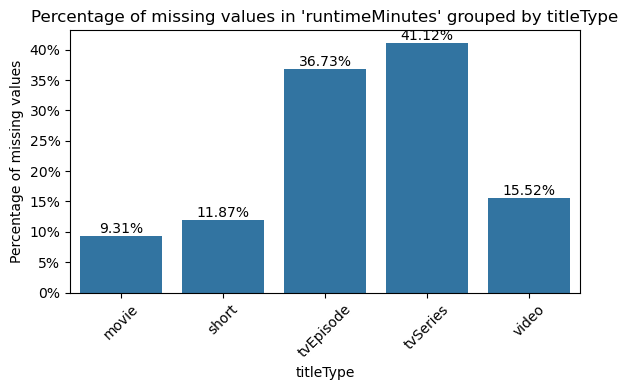

In [44]:

def plot_missing_values_grouped_by_titleType(ds, col):
    """
    Plot the percentage of missing values for the specified column grouped by titleType.
    
    Parameters:
    ds (pd.DataFrame): The dataset.
    col (str): The name of the column to check for missing values.
    """
    # Calcola la percentuale di valori mancanti per ciascun titleType
    missing_values = ds.groupby("titleType")[col].apply(lambda x: x.isna().mean() * 100)
    
    # Plot delle percentuali di valori mancanti per ciascun titleType
    plt.figure(figsize=(6, 4))
    sns.barplot(x=missing_values.index, y=missing_values.values)
    plt.xticks(rotation=45)
    plt.title(f"Percentage of missing values in '{col}' grouped by titleType")
    plt.ylabel("Percentage of missing values")
    plt.xlabel("titleType")
    # Etichette dell'asse y come percentuali
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    # Percentuale sopra ogni barra
    for i, v in enumerate(missing_values.values):
        plt.text(i, v, f"{v:.2f}%", color='black', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

plot_missing_values_grouped_by_titleType(ds, "runtimeMinutes")

In [45]:
# create runTimeHours

ds["runtimeHours"] = ds["runtimeMinutes"] / 60

ds.drop(columns=["runtimeMinutes"], inplace=True)

In [46]:
def plot_runtime_distribution(ds):
    """
    Plot runtimeMinutes distribution for each titleType in separate plots.
    
    Parameters:
    ds (pd.DataFrame): The dataset.
    """
    title_types = ds["titleType"].unique()
    num_plots = len(title_types)
    
    plt.figure(figsize=(10, 5 * num_plots))
    
    for i, titleType in enumerate(title_types):
        plt.subplot(num_plots, 1, i + 1)
        sns.histplot(ds[ds["titleType"] == titleType]["runtimeHours"], label=titleType)
        plt.title(f"Runtime distribution for {titleType}")
        plt.xlabel("runtimeHours")
        plt.ylabel("density")
        plt.legend()
    
    plt.tight_layout()
    plt.show()


In [47]:
from sklearn.mixture import GaussianMixture

def impute_missing_values(ds, col, n_components):
    """
    Imputa i valori mancanti della colonna utilizzando un modello di mescolanza gaussiana (Gaussian Mixture Model).
    
    Parametri:
    ds (pd.DataFrame): Il dataset.
    col (str): Il nome della colonna.
    n_components (int): Il numero di componenti per il modello di mescolanza gaussiana.
    """
    # Crea il modello di mescolanza gaussiana
    gmm = GaussianMixture(n_components=n_components)
    
    # Adatta il modello sui valori non mancanti
    gmm.fit(ds[col] .dropna().values.reshape(-1, 1))
    
    # Prevedi i valori mancanti
    missing_values = ds[col].isna()
    num_missing = missing_values.sum()
    
    # Genera campioni finché non otteniamo tutti valori positivi
    imputed_values = []
    while len(imputed_values) < num_missing:
        samples = gmm.sample(num_missing)[0].flatten()
        positive_samples = samples[samples > 0]
        imputed_values.extend(positive_samples)
    
    # Prendi solo il numero necessario di valori imputati
    imputed_values = imputed_values[:num_missing]
    
    # Imputa i valori mancanti
    ds.loc[missing_values, col] = imputed_values

    return ds

In [48]:
title_type_components = {
    "short": 1,
    "movie": 1,
    "tvSeries": 2,
    "tvEpisode": 4,
    "video": 2
}

# Iterazione su ciascun titleType e numero di componenti
for title_type, n_components in title_type_components.items():
    # Selezione delle righe corrispondenti al titleType corrente
    subset = ds[ds["titleType"] == title_type]
    # Imputazione dei valori mancanti per il subset corrente
    subset = impute_missing_values(subset, "runtimeHours", n_components)
    # Aggiornamento del DataFrame originale con i valori imputati
    ds.loc[ds["titleType"] == title_type, "runtimeHours"] = subset["runtimeHours"]

print("Done.")

Done.


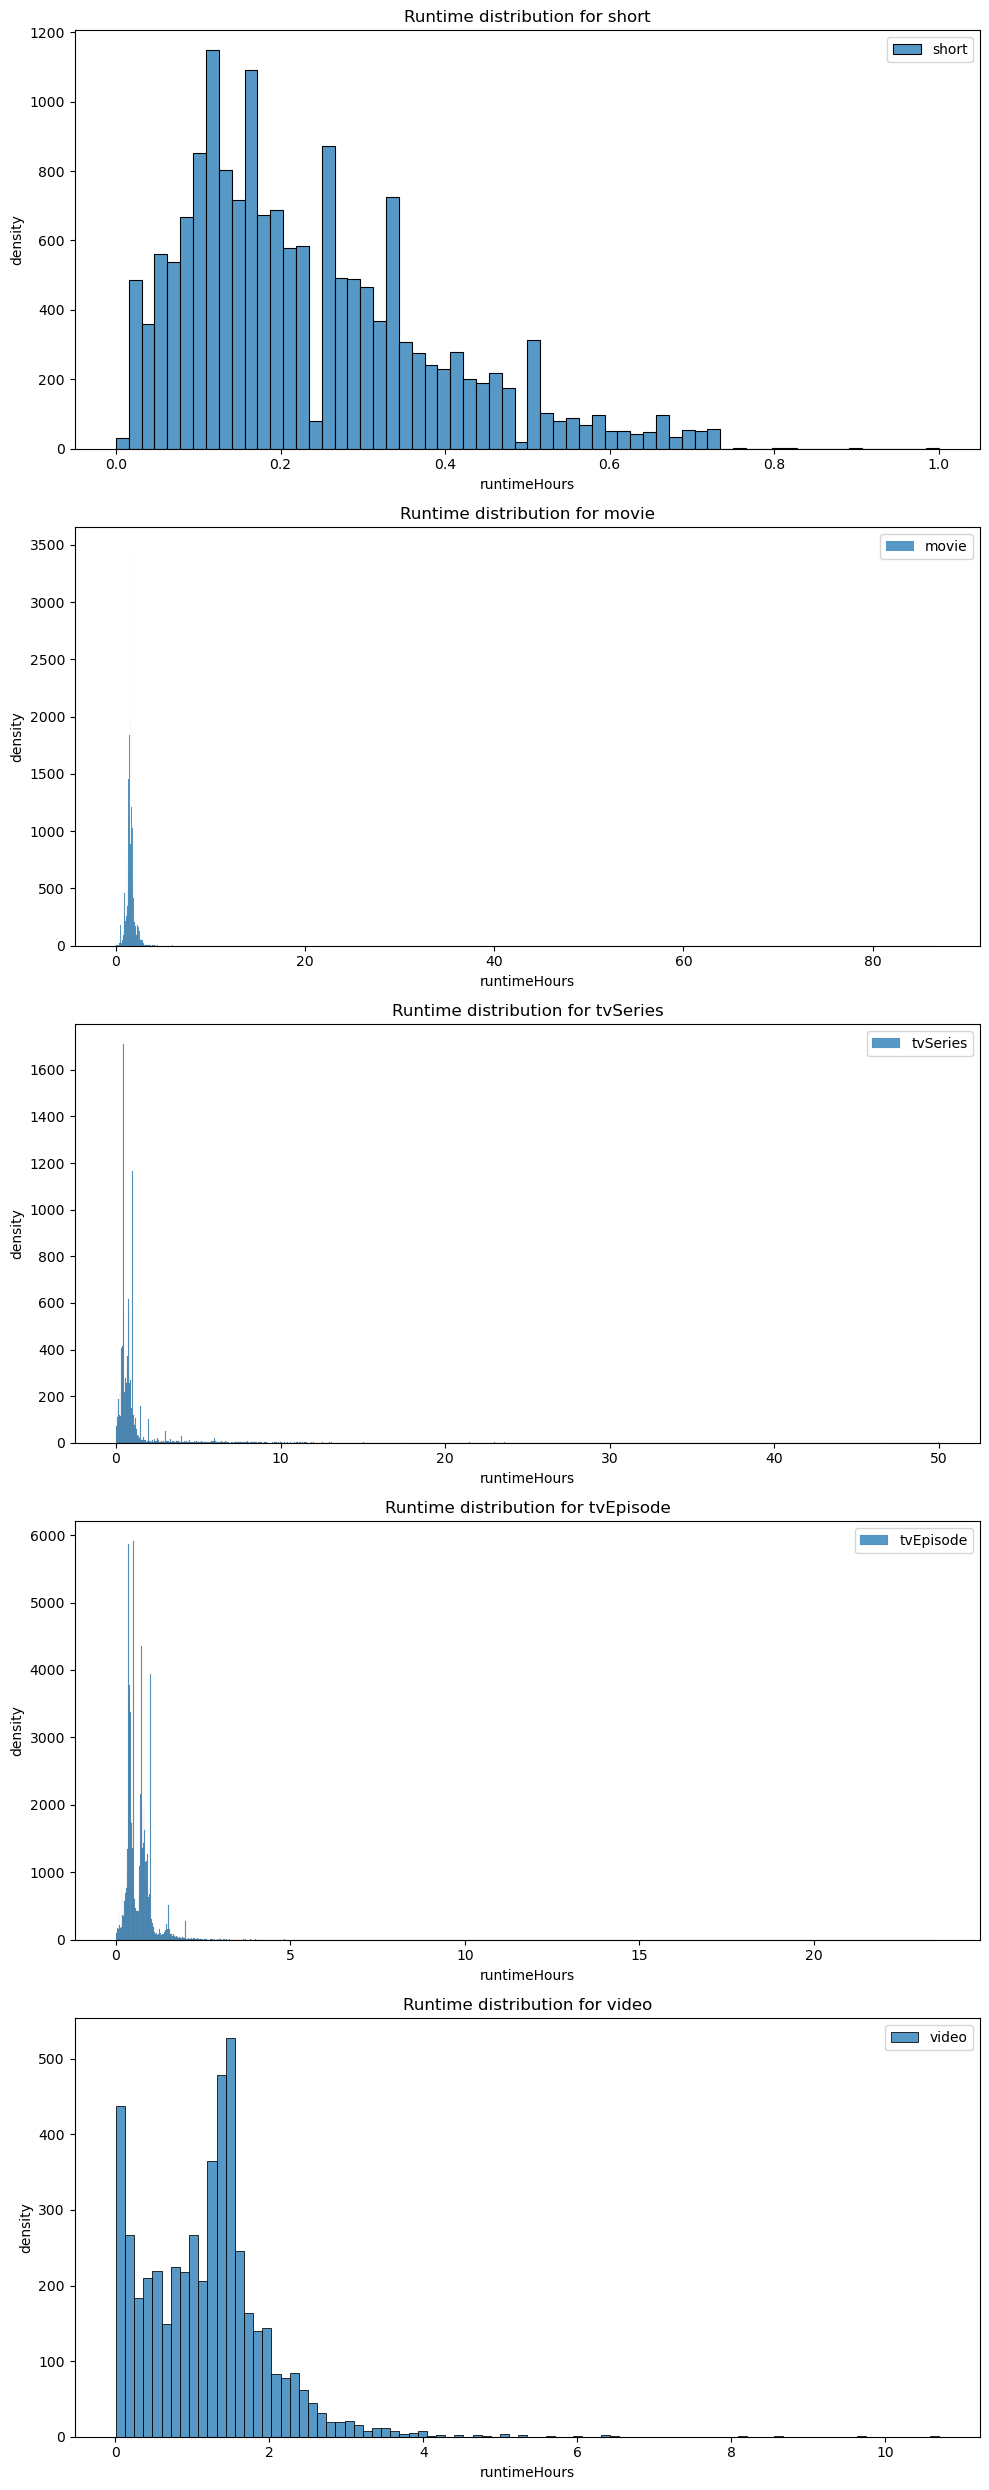

In [49]:
plot_runtime_distribution(ds)

In [50]:
plot_missing_values(ds, "./data_overview/misc/missing_values_after_runtimeMinutes.png")

In [51]:
ds_new_path = "./output/01_imdb.csv"
ds.to_csv(ds_new_path, index=False)